# OSRS NPC Classification
# Champion model -- local training run

This is a **local, GPU-executed port of `03_train.ipynb`** (the original Colab notebook). That
notebook only ever saved its checkpoint to Google Drive (`/content/drive/MyDrive/...`), so no
champion checkpoint exists anywhere in this repo. This notebook reproduces the *exact same*
architecture and training recipe locally so we have a real `npc_classifier.pth` to evaluate and
compare against the from-scratch challenger trained in `03b_train_custom_cnn.ipynb`.

Data loading, cleaning, class collapsing, and the 70/15/15 split are factored into `npc_data.py`
and shared with the challenger notebook -- this guarantees both models are trained/evaluated on
the identical rows, which is what makes a champion-challenger comparison fair.

- **Input:** chathead image + body image (separate CNN backbones, concatenated features)
- **Target:** Class (top 10 classes, everything else collapsed to "Other")
- **Split:** 70/15/15 train/val/test, stratified, `random_state=42`
- **Backbone (champion):** two pretrained ResNet18 (ImageNet weights) -- the "transfer learning"
  side of the comparison against `03b`'s from-scratch CNN backbones.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt

from npc_data import (
    load_clean_npc_df, add_top_class_labels, stratified_split,
    get_transforms, NPCDataset, class_weights,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [2]:
df = load_clean_npc_df(data_dir="../data")
print(f"Working dataset: {len(df)} NPCs")

df, CLASS_NAMES, class_to_idx = add_top_class_labels(df, n=10)
print(df["label"].value_counts())

Working dataset: 3459 NPCs
label
Human         2095
Other          575
Dwarf          248
Elf            149
Gnome          139
Vampyre         61
Ghost           49
Monkey          42
Dorgeshuun      40
Troll           31
Cat             30
Name: count, dtype: int64


## Split data into training/val/test

In [3]:
train_df, val_df, test_df = stratified_split(df, seed=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2421 | Val: 519 | Test: 519


## Augmentation

Class imbalance is heavy -- some classes (Cat, Troll) have ~30 NPCs while Human has 2,000+.
Training-only augmentation, heavier for minority classes:

**All training images:** random horizontal flip (p=0.3), random rotation (+/-15 deg), color jitter.

**Minority classes (everything except Human and Other):** random affine (rotation/translate/scale)
+ random perspective (p=0.5) -- simulates pose/viewpoint variation, effectively oversampling rare
classes like Vampyre, Cat, Troll without duplicating identical images.

In [4]:
train_transform, eval_transform = get_transforms(img_size=128)
MINORITY_CLASSES = set(CLASS_NAMES) - {"Human", "Other"}

train_ds = NPCDataset(train_df, train_transform, data_dir="../data", is_train=True, minority_classes=MINORITY_CLASSES)
val_ds = NPCDataset(val_df, eval_transform, data_dir="../data", is_train=False)
test_ds = NPCDataset(test_df, eval_transform, data_dir="../data", is_train=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, num_workers=0)

## Model architecture -- champion (transfer learning)

### Backbone
Two separate ResNet18 backbones pretrained on ImageNet -- one for chathead images, one for body
images. The final classification layer of each is replaced with `nn.Identity()` to extract
512-dim feature vectors.

### Fusion
The two 512-dim vectors are concatenated (1024-dim) then passed through:
Linear(1024->256) -> ReLU -> Dropout(0.5) -> Linear(256->n_classes)

### Training
- **Loss:** CrossEntropyLoss with inverse-frequency class weights
- **Optimizer:** Adam, lr=5e-5
- **Scheduler:** ReduceLROnPlateau (halves LR if val loss plateaus for 2 epochs)
- **Early stopping:** patience=3 on val loss, saves best checkpoint
- **Input size:** 128x128

In [5]:
class DualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = models.resnet18(weights="IMAGENET1K_V1")
        self.body_cnn = models.resnet18(weights="IMAGENET1K_V1")
        self.chathead_cnn.fc = nn.Identity()
        self.body_cnn.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        f1 = self.chathead_cnn(chathead)
        f2 = self.body_cnn(body)
        return self.classifier(torch.cat([f1, f2], dim=1))


def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for chathead, body, labels in loader:
            chathead, body, labels = chathead.to(DEVICE), body.to(DEVICE), labels.to(DEVICE)
            preds = model(chathead, body)
            loss = criterion(preds, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / len(loader), correct / total

In [6]:
model = DualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)

weights = class_weights(df, len(CLASS_NAMES), DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Champion (DualCNN, pretrained ResNet18 x2) params: {n_params:,}")

Champion (DualCNN, pretrained ResNet18 x2) params: 22,618,251


In [7]:
CHECKPOINT_PATH = "../data/npc_classifier.pth"

best_val_loss = float("inf")
patience = 3
epochs_no_improve = 0
history = []

EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, train=False)
    history.append((epoch + 1, train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch+1}/{EPOCHS} | train loss: {train_loss:.3f} acc: {train_acc:.3f} | val loss: {val_loss:.3f} acc: {val_acc:.3f}")
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        epochs_no_improve = 0
        print("  saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping.")
            break

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20 | train loss: 2.038 acc: 0.348 | val loss: 1.465 acc: 0.715
  saved best model


Epoch 2/20 | train loss: 0.992 acc: 0.648 | val loss: 0.752 acc: 0.803
  saved best model


Epoch 3/20 | train loss: 0.497 acc: 0.800 | val loss: 0.609 acc: 0.865
  saved best model


Epoch 4/20 | train loss: 0.328 acc: 0.872 | val loss: 0.535 acc: 0.881
  saved best model


Epoch 5/20 | train loss: 0.235 acc: 0.903 | val loss: 0.569 acc: 0.875


Epoch 6/20 | train loss: 0.170 acc: 0.910 | val loss: 0.541 acc: 0.892


Epoch 7/20 | train loss: 0.134 acc: 0.926 | val loss: 0.563 acc: 0.873
Early stopping.


In [8]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))

test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer, train=False)
print(f"Champion test accuracy: {test_acc:.3f}")

Champion test accuracy: 0.844


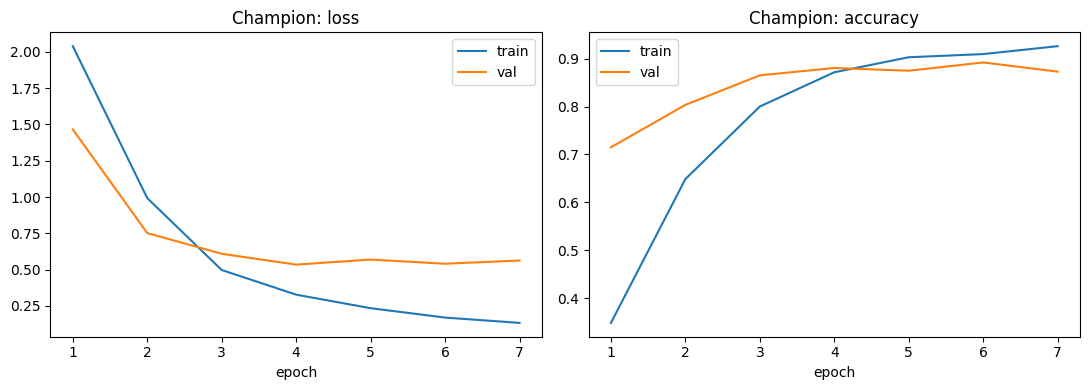

In [9]:
epochs_r, train_losses, train_accs, val_losses, val_accs = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_r, train_losses, label="train")
axes[0].plot(epochs_r, val_losses, label="val")
axes[0].set_title("Champion: loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs_r, train_accs, label="train")
axes[1].plot(epochs_r, val_accs, label="val")
axes[1].set_title("Champion: accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("../img/champion_training_curves.png")
plt.show()